# 02 Baseline Statistical Models
This notebook compares the saved TF-IDF baseline results without fitting any model.

## Why Baselines Matter
Sparse linear models are efficient, interpretable reference systems for short, noisy, imbalanced text classification.

## TF-IDF Feature Extraction
The saved baseline pipelines use word unigrams and bigrams with a 100,000-feature cap. The vectorizer was fitted on training text only.

## Models Evaluated
The project evaluated Linear SVM, Logistic Regression, and Multinomial Naive Bayes using identical saved splits.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
RESULTS = ROOT / 'outputs' / 'results'
ERRORS = ROOT / 'outputs' / 'error_analysis'

baseline = pd.read_csv(RESULTS / 'baseline_leaderboard.csv', encoding='utf-8')
baseline_metrics = json.loads((RESULTS / 'baseline_metrics.json').read_text(encoding='utf-8'))
comparison = pd.read_csv(RESULTS / 'model_comparison_leaderboard.csv', encoding='utf-8')
error_summary = json.loads((ERRORS / 'baseline_error_summary.json').read_text(encoding='utf-8'))

## Baseline Leaderboard
Test Macro-F1 is the primary ranking column because each class must contribute equally.

In [2]:
test_baselines = baseline.query("split == 'test'").sort_values('macro_f1', ascending=False).copy()
display(test_baselines[['model_name', 'accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'weighted_f1']].style.format('{:.4f}', subset=['accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'weighted_f1']))

,model_name,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
1,linear_svm,0.8531,0.5005,0.5090,0.5040,0.8527
3,logistic_regression,0.7740,0.4416,0.5367,0.4613,0.8013
5,multinomial_nb,0.8787,0.5605,0.3854,0.4014,0.8417


## Accuracy vs Macro-F1
Naive Bayes reaches the highest baseline accuracy but has the lowest baseline Macro-F1, showing that majority-class success can hide minority-class failure.

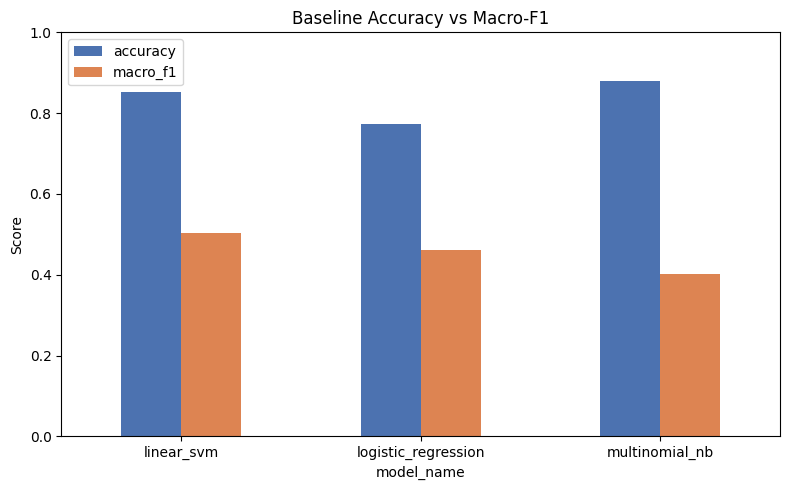

In [3]:
plot_data = test_baselines.set_index('model_name')[['accuracy', 'macro_f1']]
plot_data.plot(kind='bar', figsize=(8, 5), color=['#4c72b0', '#dd8452'])
plt.title('Baseline Accuracy vs Macro-F1')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Linear SVM as Strongest Baseline
Linear SVM records 0.5040 test Macro-F1 and 0.8531 accuracy. It is also the strongest model in the complete seven-model comparison.

In [4]:
svm = comparison.loc[comparison['model_name'].eq('linear_svm')].iloc[0]
nb = comparison.loc[comparison['model_name'].eq('multinomial_nb')].iloc[0]
pd.DataFrame({
    'Linear SVM': svm[['test_accuracy', 'test_macro_f1', 'negative_f1', 'neutral_f1', 'positive_f1']],
    'Multinomial NB': nb[['test_accuracy', 'test_macro_f1', 'negative_f1', 'neutral_f1', 'positive_f1']],
}).T.style.format('{:.4f}')

,test_accuracy,test_macro_f1,negative_f1,neutral_f1,positive_f1
Linear SVM,0.8531,0.5040,0.4662,0.1303,0.9156
Multinomial NB,0.8787,0.4014,0.2702,0.0000,0.9339


## Baseline Error Findings
The saved Linear SVM test analysis reports 11,414 errors. Neutral has the worst error rate, and Negative/Positive polarity swaps account for most mistakes.

In [5]:
svm_errors = error_summary['models']['linear_svm']['test']
pd.DataFrame(svm_errors['confusion_pairs']).head(6).style.format({'share_of_errors': '{:.2%}'})

,true_label,predicted_label,count,share_of_errors
0,Negative,Positive,5599,49.05%
1,Positive,Negative,5388,47.21%
2,Positive,Neutral,183,1.60%
3,Neutral,Positive,157,1.38%
4,Negative,Neutral,62,0.54%
5,Neutral,Negative,25,0.22%


## Key Takeaways
Linear SVM is the strongest baseline and final model. Multinomial NB's 0.8787 accuracy is misleading beside its 0.4014 Macro-F1 and 0.0000 Neutral F1.